In [1]:
# Autoreload all modules
%load_ext autoreload
%autoreload 2

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
from flax.training import train_state
import optax
import matplotlib.pyplot as plt

import sys
sys.path.append('../../')
sys.path.append('../../mcjax/process')

from mcjax.proba.gaussian import IsotropicGauss, Gauss
from mcjax.proba.doublewell import DoubleWell
from mcjax.process.models import MLPModel, ResBlockModel
from mcjax.process.ou import OU
from mcjax.process.algo import DDSAlgorithm,IDEMAlgorithm,PISAlgorithm, ControlledMonteCarloDiffusion

/home/lghangao/snap/snapd-desktop-integration/mcjax/mcjax_denoising/notebooks/denoising/../../mcjax/proba/doublewell.py:14: SyntaxWarning: invalid escape sequence '\d'
  """
/home/lghangao/snap/snapd-desktop-integration/mcjax/mcjax_denoising/notebooks/denoising/../../mcjax/proba/doublewell.py:64: SyntaxWarning: invalid escape sequence '\s'
  """


### Test DoubleWell Distribution

Unnormalized density:
$$
    \rho(x) = \exp( -\sum_{i=1}^m (x_i^2 - \delta)^2 - 1/2 \sum_{i=m+1}^d x_i^2 )
$$

In [ ]:
dw = DoubleWell(dim=5, m=5, delta=9.0)

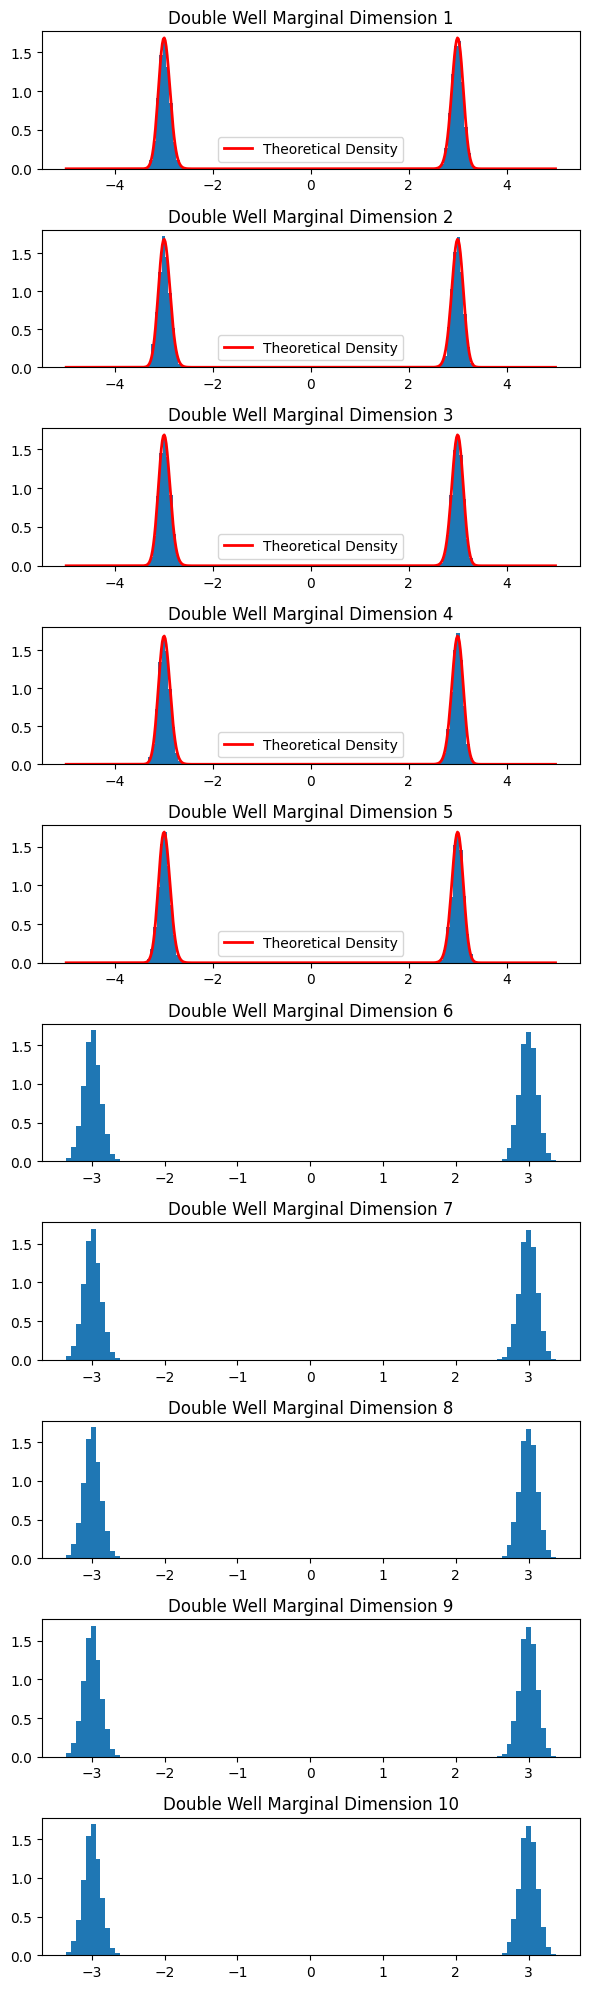

In [17]:
# Plot the marginal of samples 
fig, axes = plt.subplots(10, 1, figsize=(6, 20))
for i in range(10):
    x = dw.sample(jr.PRNGKey(0), n_samples=10000)[:,i]
    axes[i].hist(x, bins=100, density=True)
    axes[i].set_title(f'Double Well Marginal Dimension {i+1}')
    # for the first 5 dimensions, overlay the theoretical density
    if i < 5:
        x_vals = jnp.linspace(-5, 5, 500)
        theoretical_density = jnp.exp(dw.batch(x_vals[:, None]))  # add batch dimension
        dx = x_vals[1] - x_vals[0]
        normalization = jnp.sum(theoretical_density) * dx
        theoretical_density = theoretical_density / normalization
        axes[i].plot(x_vals, theoretical_density, 'r-', lw=2, label='Theoretical Density')
        axes[i].legend()
plt.tight_layout()
plt.show()


